POWER SYSTEM FOR CONVERTER-DRIVEN STABILITY STUDY

In [1]:
import villas.dataprocessing.readtools as rt
import villas.dataprocessing.plottools as pt
from villas.dataprocessing.timeseries import TimeSeries as ts
import math
import dpsimpy

Infeed Power System equivalent

In [2]:
# Nodes
gnd = dpsimpy.emt.SimNode.gnd
n1 = dpsimpy.emt.SimNode('n1')
n2 = dpsimpy.emt.SimNode('n2')
n3 = dpsimpy.emt.SimNode('n3')

# Components
vs = dpsimpy.emt.ph3.VoltageSource('vs')
vs.set_parameters(dpsimpy.Math.single_phase_variable_to_three_phase(complex(100000, 0)), 50)
r1 = dpsimpy.emt.ph3.Resistor('r_1')
r1.set_parameters(dpsimpy.Math.single_phase_parameter_to_three_phase(0.005))
l1 = dpsimpy.emt.ph3.Inductor('l_1')
l1.set_parameters(dpsimpy.Math.single_phase_parameter_to_three_phase(0.01))

# Connections
vs.connect([gnd, n1])
r1.connect([n1, n2])
l1.connect([n2, n3])

Pi equivalent circuits for transmission line

In [ ]:
line_res= 0.05
line_ind= 0.1
line_cap = 0.1e-6
# line between infeed and left converter
line_emt1 = dpsimpy.emt.ph3.PiLine('PiLine1')
line_emt1.set_parameters(
    series_resistance=dpsimpy.Math.single_phase_parameter_to_three_phase(line_res,
    series_inductance=dpsimpy.Math.single_phase_parameter_to_three_phase(line_ind),
    parallel_capacitance=dpsimpy.Math.single_phase_parameter_to_three_phase(line_cap))

# line between infeed and right  converter
line_emt2 = dpsimpy.emt.ph3.PiLine('PiLine2')
line_emt2.set_parameters(
    series_resistance=dpsimpy.Math.single_phase_parameter_to_three_phase(line_resistance),
    series_inductance=dpsimpy.Math.single_phase_parameter_to_three_phase(line_inductance),
    parallel_capacitance=dpsimpy.Math.single_phase_parameter_to_three_phase(line_capacitance))

Converter

In [4]:
# Nodes left Converter
n4 = dpsimpy.emt.SimNode('n4')
n5 = dpsimpy.emt.SimNode('n5')
n6 = dpsimpy.emt.SimNode('n6')

# Node right Converter
n7 = dpsimpy.emt.SimNode('n7')
n8 = dpsimpy.emt.SimNode('n8')
n9 = dpsimpy.emt.SimNode('n9')

# Components left converter
vs1 = dpsimpy.emt.ph3.VoltageSource('vs_1')
vs1.set_parameters(dpsimpy.Math.single_phase_variable_to_three_phase(complex(50000, 0)), 50)
r2 = dpsimpy.emt.ph3.Resistor('r_2')
r2.set_parameters(dpsimpy.Math.single_phase_parameter_to_three_phase(0.005))
l2 = dpsimpy.emt.ph3.Inductor('l_2')
l2.set_parameters(dpsimpy.Math.single_phase_parameter_to_three_phase(0.01))

# Components right converter
vs2 = dpsimpy.emt.ph3.VoltageSource('vs_2')
vs2.set_parameters(dpsimpy.Math.single_phase_variable_to_three_phase(complex(300000, 0)), 50)
r3 = dpsimpy.emt.ph3.Resistor('r_3')
r3.set_parameters(dpsimpy.Math.single_phase_parameter_to_three_phase(0.005))
l3 = dpsimpy.emt.ph3.Inductor('l_3')
l3.set_parameters(dpsimpy.Math.single_phase_parameter_to_three_phase(0.01))


# Connections
vs1.connect([gnd, n4])
r2.connect([n4, n5])
l2.connect([n5, n6])

vs2.connect([gnd, n7])
r3.connect([n7, n8])
l3.connect([n8, n9])


Load

In [5]:


n10 = dpsimpy.emt.SimNode('n10')
n11 = dpsimpy.emt.SimNode('n11')

# Breaker
breaker_open = 1e9
breaker_closed = 0.001
fault = dpsimpy.emt.ph3.Switch("Br_fault", dpsimpy.LogLevel.debug)
fault.set_parameters(dpsimpy.Math.single_phase_parameter_to_three_phase(breaker_open),
                     dpsimpy.Math.single_phase_parameter_to_three_phase(breaker_closed))
fault.close()

# Shunt
r4 = dpsimpy.emt.ph3.Resistor('r_3')
r4.set_parameters(dpsimpy.Math.single_phase_parameter_to_three_phase(0.005))
l4 = dpsimpy.emt.ph3.Inductor('l_4')
l4.set_parameters(dpsimpy.Math.single_phase_parameter_to_three_phase(0.01))




In [6]:
line_emt1.connect([n3, n6])
line_emt2.connect([n3, n9])
fault.connect([n3, n10])
r4.connect([n10, n11])
l4.connect([n11, gnd])

Converter

In [7]:
# DPsim EMT simulation
name = 'Compare_DP_EMT_RMS_ConverterDrivenStability_Powersystem'

# Define system topology
system = dpsimpy.SystemTopology(50, [gnd, n1, n2, n3, n4, n5, n6, n7, n8, n9, n10, n11], [vs, vs1, vs2,  r1, r2, r3, r4, l1, l2, l3, l4, fault,line_emt1, line_emt2])
# Logging
logger = dpsimpy.Logger(name)
logger.log_attribute('n3.v', 'v', n3)
logger.log_attribute('n6.v', 'v', n6)

sim = dpsimpy.Simulation(name)
sim.set_system(system)
sim.set_domain(dpsimpy.Domain.EMT)
sim.set_time_step(0.0001)
sim.set_final_time(0.1)
sim.add_logger(logger)

sim.run()

[18:17:06.519297 MnaSolverFactory info] creating KLUAdapter solver implementation


In [8]:
work_dir = 'logs/'
log_name = 'Compare_DP_EMT_RMS_ConverterDrivenStability_Powersystem'
print(work_dir + log_name + '.csv')

ts_dpsim_emt = rt.read_timeseries_dpsim(work_dir + log_name + '.csv')

logs/Compare_DP_EMT_RMS_ConverterDrivenStability_Powersystem.csv
column number: 2
results length: 1001
real column names: ['n3.v', 'n6.v']
complex column names: []


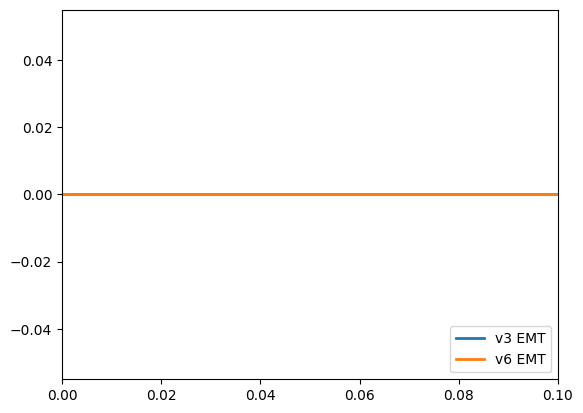

In [9]:
ts_dpsim_emt['n3.v'].label = 'v3 EMT'
ts_dpsim_emt['n6.v'].label = 'v6 EMT'
pt.plot_timeseries(1, ts_dpsim_emt['n3.v'])
pt.plot_timeseries(1, ts_dpsim_emt['n6.v'])